In [43]:
!pip install ultralytics scikit-learn --quiet

In [44]:
from ultralytics import YOLO
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import urllib.request
import zipfile
import os
import sys
import copy
import json as _json
from pathlib import Path
from tqdm import tqdm
from sklearn.cluster import KMeans

sys.path.append('..')  # repo root

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {device}')

Device: cpu


In [45]:
# Downloads automatically from Ultralytics on first run, then cached in ~/.cache/ultralytics
# Creates instance of the YOLO wrapper class, which loads the model
model = YOLO('yolov8n.pt')
model.info()

# model.model is the actual nn.Module (DetectionModel) inside the YOLO wrapper
inner_model = model.model.to(device)
print(f'Inner model type: {type(inner_model).__name__}')

YOLOv8n summary: 129 layers, 3,157,200 parameters, 0 gradients, 8.9 GFLOPs
Inner model type: DetectionModel


We want to iteratively go through each layer in the model and quantise its weights and activations

Weight quantisation uses a simple quantisation algorithm, can be:
- Linear
- Logarithmic

Activation quantisation is more involved, steps are:
- With original model, pass through calibration data and record activations throughout the model
- Use the recorded activations and for each layer, find the dimension with the most outliers
- With the dimension with the most outliers, group them using k-means and calculate there quantisation scale and zero point
- With these values, for the respective layer, we can quantise the activations by which group they belong to.

In [46]:
N_CALIBRATION = 64   # paper uses 64 calibration samples

def get_calibration_images(n: int = N_CALIBRATION) -> list:
    """
    Return a list of image file paths for calibration.

    Priority:
      1. Local cocosample/ folder (teammate's original approach)
      2. Download n images from COCO val2017
    """
    local = Path('cocosample')
    if local.exists() and len(list(local.glob('*.jpg'))) > 0:
        imgs = sorted(local.glob('*.jpg'))[:n]
        print(f'Using local cocosample/ — found {len(imgs)} images')
        return [str(p.resolve()) for p in imgs]

    print('cocosample/ not found — downloading COCO val2017 images...')
    download_dir = Path('coco_calib')
    download_dir.mkdir(exist_ok=True)

    base_url = 'http://images.cocodataset.org/val2017/'
    ann_url  = 'http://images.cocodataset.org/annotations/annotations_trainval2017.zip'
    ann_dir  = Path('coco_annotations')

    if not ann_dir.exists():
        print('  Downloading COCO annotations (~250MB, done once)...')
        ann_zip = Path('annotations.zip')
        urllib.request.urlretrieve(ann_url, ann_zip)
        with zipfile.ZipFile(ann_zip, 'r') as z:
            z.extract('annotations/instances_val2017.json', 'coco_annotations')
        ann_zip.unlink()

    with open('coco_annotations/annotations/instances_val2017.json') as f:
        coco = _json.load(f)

    image_files = []
    for img_info in coco['images'][:n]:
        fname = img_info['file_name']
        fpath = download_dir / fname
        if not fpath.exists():
            urllib.request.urlretrieve(base_url + fname, fpath)
        image_files.append(str(fpath.resolve()))

    print(f'  Downloaded {len(image_files)} calibration images to coco_calib/')
    return image_files


calibration = get_calibration_images(N_CALIBRATION)
print(f'Calibration set: {len(calibration)} images')

# Map to save layer activations
activations = {}

def get_activations(name):
    def hook(module, input, output):
        # Handle tensor output or tuple/list output
        if isinstance(output, torch.Tensor):
            out = output
        elif isinstance(output, (tuple, list)) and len(output) > 0:
            out = output[0]
        else:
            return
        if isinstance(out, torch.Tensor):
            activations[name] = out.detach().cpu()
    return hook

handles = []

# FIX: register hooks on model.model (the inner nn.Module)
for name, layer in model.model.named_modules():
    if len(list(layer.children())) == 0:
        handles.append(layer.register_forward_hook(get_activations(name)))

print(f'Registered {len(handles)} hooks on model.model')

cocosample/ not found — downloading COCO val2017 images...
  Downloaded 64 calibration images to coco_calib/
Calibration set: 64 images
Registered 129 hooks on model.model


In [33]:
# Automatically find images — works on any machine
def get_image_paths(folder: str = "cocosample") -> list[str]:
    """
    Returns absolute paths to all jpg/png images in the given folder.
    Uses Path so it works on Windows, Mac, and Linux without changes.
    """
    folder = Path(folder)
    if not folder.exists():
        raise FileNotFoundError(
            f"Could not find '{folder}'. "
            f"Current directory is: {os.getcwd()}"
        )
    paths = sorted(folder.glob("*.jpg")) + sorted(folder.glob("*.png"))
    if not paths:
        raise FileNotFoundError(f"No images found in '{folder}'")
    return [str(p) for p in paths]

calibration_paths = get_image_paths("coco_calib")

# Run inference
for img_path in calibration_paths:
    with torch.no_grad():
        model(img_path)   # pass full path directly — no string concatenation

for h in handles:
    h.remove()


image 1/1 c:\Users\bboya\OneDrive - University of Southampton\University\Year 4\COMP6258 Differentiable Programming and Deep Learning\Coursework\COMP6258-Coursework\coco_calib\000000006818.jpg: 640x448 1 toilet, 113.1ms
Speed: 1.2ms preprocess, 113.1ms inference, 0.2ms postprocess per image at shape (1, 3, 640, 448)

image 1/1 c:\Users\bboya\OneDrive - University of Southampton\University\Year 4\COMP6258 Differentiable Programming and Deep Learning\Coursework\COMP6258-Coursework\coco_calib\000000016228.jpg: 448x640 11 persons, 1 bench, 1 horse, 2 umbrellas, 122.3ms
Speed: 5.2ms preprocess, 122.3ms inference, 0.2ms postprocess per image at shape (1, 3, 448, 640)

image 1/1 c:\Users\bboya\OneDrive - University of Southampton\University\Year 4\COMP6258 Differentiable Programming and Deep Learning\Coursework\COMP6258-Coursework\coco_calib\000000017627.jpg: 480x640 3 persons, 9 cars, 134.7ms
Speed: 2.0ms preprocess, 134.7ms inference, 0.2ms postprocess per image at shape (1, 3, 480, 640)



In [47]:
# Run inference on all calibration images by calling model.predict() on the YOLO wrapper
# model.predict() internally calls model.model.forward() which fires the hooks
print('Running calibration pass...')
for img in tqdm(calibration):
    with torch.no_grad():
        model.predict(img, verbose=False)

# Always remove hooks after inference to avoid memory leaks
for h in handles:
    h.remove()

print(f'Calibration complete — {len(activations)} layers captured')
print('Sample layers:')
for i, (name, act) in enumerate(activations.items()):
    print(f'  {name:<50} {tuple(act.shape)}')
    if i >= 7: break


Running calibration pass...


100%|██████████| 64/64 [00:16<00:00,  3.90it/s]

Calibration complete — 72 layers captured
Sample layers:
  model.0.conv                                       (1, 16, 240, 320)
  model.0.act                                        (1, 80, 15, 20)
  model.1.conv                                       (1, 32, 120, 160)
  model.2.cv1.conv                                   (1, 32, 120, 160)
  model.2.m.0.cv1.conv                               (1, 16, 120, 160)
  model.2.m.0.cv2.conv                               (1, 16, 120, 160)
  model.2.cv2.conv                                   (1, 32, 120, 160)
  model.3.conv                                       (1, 64, 60, 80)


In [ ]:
def get_image_paths(folder: str = "cocosample") -> list[str]:
    """
    Returns absolute paths to all jpg/png images in the given folder.
    Uses Path so it works on Windows, Mac, and Linux without changes.
    """
    folder = Path(folder)
    if not folder.exists():
        raise FileNotFoundError(
            f"Could not find '{folder}'. "
            f"Current directory is: {os.getcwd()}"
        )
    paths = sorted(folder.glob("*.jpg")) + sorted(folder.glob("*.png"))
    if not paths:
        raise FileNotFoundError(f"No images found in '{folder}'")
    return [str(p) for p in paths]

calibration_paths = get_image_paths("coco_calib")

# Run inference
for img_path in calibration_paths:
    with torch.no_grad():
        model(img_path)   # pass full path directly

for h in handles:
    h.remove()

In [49]:
'''
#Define function for maximum activation dimension
def MaxActivationDimensionCNN(layer):
        #Layer will be an array of weights

        #Pixel Dimension
        pixel_dim = layer.view(1,-1).squeeze()
        pixel_var = max(pixel_dim) - min(pixel_dim)
        
        #Channel Dim
        channel_dim = layer.view((layer.shape[0], -1)) #channel is dependent on the output channels
        channel_var = (max(torch.max(channel_dim, 0)[0]) - min(torch.max(channel_dim, 0)[0])) + (max(torch.min(channel_dim, 0)[0]) - min(torch.min(channel_dim, 0)[0]))
        
        if channel_var > pixel_var:
            return 0, channel_dim
        else:
            return 1, pixel_dim
    
#Visualise on 2 layers
count = 0
for name, activation in activations.items():
    print(name, activation.shape)
    print(MaxActivationDimensionCNN(activation))
    if count >= 10:
         break
    count+=1
'''

def MaxActivationDimensionCNN(layer):
    """
    Select the dimension with the highest activation variability — Equation 4.

    per-vector maxima, then measures how those vary across vectors.
    """
    # Pixel Dimension — per-vector maxima across channels
    if layer.dim() == 4:       # (B, C, H, W) CNN feature map
        B, C, H, W = layer.shape
        pixel_mat = layer.permute(0,2,3,1).reshape(-1, C)  # (B*H*W, C)
    elif layer.dim() == 3:     # (B, seq, dim) transformer
        pixel_mat = layer.reshape(-1, layer.shape[-1])
    else:
        pixel_mat = layer.view(1, -1)

    pixel_var = (
        (torch.max(pixel_mat, dim=1).values.max() - torch.max(pixel_mat, dim=1).values.min()) +
        (torch.min(pixel_mat, dim=1).values.max() - torch.min(pixel_mat, dim=1).values.min())
    ).item()

    # Channel Dimension — unchanged from original (was correct)
    channel_dim = layer.view((layer.shape[0], -1))
    channel_var = (
        (max(torch.max(channel_dim, 0)[0]) - min(torch.max(channel_dim, 0)[0])) +
        (max(torch.min(channel_dim, 0)[0]) - min(torch.min(channel_dim, 0)[0]))
    ).item()

    if channel_var > pixel_var:
        return 0, channel_dim
    else:
        return 1, layer.view(layer.shape[0], -1)

# Visualise on first 10 captured layers
count = 0
for name, activation in activations.items():
    if activation.dim() < 2:
        continue
    d, dim = MaxActivationDimensionCNN(activation)
    dim_name = 'pixel' if d == 1 else 'channel'
    print(f'{name:<50} shape={tuple(activation.shape)}  selected={dim_name}')
    count += 1
    if count >= 10:
        break


model.0.conv                                       shape=(1, 16, 240, 320)  selected=channel
model.0.act                                        shape=(1, 80, 15, 20)  selected=channel
model.1.conv                                       shape=(1, 32, 120, 160)  selected=channel
model.2.cv1.conv                                   shape=(1, 32, 120, 160)  selected=channel
model.2.m.0.cv1.conv                               shape=(1, 16, 120, 160)  selected=channel
model.2.m.0.cv2.conv                               shape=(1, 16, 120, 160)  selected=channel
model.2.cv2.conv                                   shape=(1, 32, 120, 160)  selected=channel
model.3.conv                                       shape=(1, 64, 60, 80)  selected=channel
model.4.cv1.conv                                   shape=(1, 64, 60, 80)  selected=channel
model.4.m.0.cv1.conv                               shape=(1, 32, 60, 80)  selected=channel


In [ ]:
'''
class Quantizer:

    def __init__(self):
        self.statistics = {}

    def MaxActivationDimensionCNN(self, layer):
        #Layer will be an array of weights

        #Pixel Dimension
        pixel_dim = layer.view(1,-1).squeeze()
        pixel_var = max(pixel_dim) - min(pixel_dim)
        
        #Channel Dim
        channel_dim = layer.view((layer.shape[0], -1)) #channel is dependent on the output channels
        channel_var = (max(torch.max(channel_dim, 0)[0]) - min(torch.max(channel_dim, 0)[0])) + (max(torch.min(channel_dim, 0)[0]) - min(torch.min(channel_dim, 0)[0]))
        
        if channel_var > pixel_var:
            return 0, channel_dim
        else:
            return 1, pixel_dim

    def logarithmic_quantization(self, activations, q_s, q_z, num_bits=2):
        q_activations = torch.clamp(torch.round(-torch.log2(activations/q_s)), 0, pow(2, num_bits)-1)
        return (q_activations - q_z) *q_s

    def linear_quantization(self, activations, q_s, q_z, num_bits=2):
        q_activations = torch.clamp(torch.round(activations/q_s) + q_z , 0, pow(2, num_bits)-1)
        return q_s*pow(2,-1*q_activations)        
    
    def quantize(self, activations, quant_func, n_groups=2, n_bits=2): # Can speed up later by passing in layer reference too quantise weights live
        
        if len(activations.size()) < 2:
            acts = activations.unsqueeze(0)
        else:
            acts = activations.squeeze()

        q_activations = torch.zeros_like(acts)

        for i in range(len(acts)):
            channel = acts[i]
            #print(channel.shape)

            d_max = max(channel.view(1,-1))
            d_min = min(channel.view(1,-1))

            q_s = (d_max - d_min)/(pow(2,n_bits))
            z   = -d_min/q_s

            q_activations[i] = quant_func(channel, q_s, z, n_bits)       

        return q_activations

    def group_quantize(self, activations, quant_func, n_groups=2, n_bits=2): # Can speed up later by passing in layer reference too quantise weights live
        
        if len(activations.size()) < 2:
            acts = activations.unsqueeze(1)

        else:
            acts = activations

        q_activations = torch.zeros_like(acts)

        #Group channels
        kmeans = KMeans(n_clusters=n_groups, random_state=0, n_init="auto")
        kmeans.fit(acts)
        groups = kmeans.predict(acts)
    
        quant_groups = {}

        for i in range(len(groups)):

            if groups[i] in quant_groups: #if cluster centre already mapped

                if max(acts[i])>quant_groups[groups[i]]["max"]:
                    quant_groups[groups[i]]["max"] = max(acts[i])


                elif min(acts[i])<quant_groups[groups[i]]["min"]:
                    quant_groups[groups[i]]["min"] = min(acts[i])
            
            
            else: #if cluster centre hasnt been mapped yet
                quant_groups[groups[i]] = {"min": min(acts[i]), "max": max(acts[i])}


        quant_params = {}

        for group, params in quant_groups.items():
            q_s = (params["max"] - params["min"])/(pow(2,n_bits))
            z   = -params["min"]/q_s
            quant_params[group] = {"q_s":q_s, "z":z}

        # print(quant_params)

        #apply scaling
        for i in range(len(groups)):
            q_activations[i] = quant_func(activations[i], quant_params[groups[i]]["q_s"], quant_params[groups[i]]["z"], n_bits)       

        return q_activations
    
    def quantize_model(self, model, quant_method, quantizer, num_groups, num_bits):
        q_model = copy.deepcopy(model)

        progress_bar = tqdm(total=len(list(q_model.named_parameters())))

        for name, param in q_model.named_parameters():
            d, dim = self.MaxActivationDimensionCNN(param)
            param.data  = nn.parameter.Parameter(quant_method(dim.detach(), quantizer, num_groups, num_bits).view(param.shape))

            self.statistics[name] = "pixel_dim" if d else "channel_dim"
            progress_bar.update(1)

        return q_model
'''

In [50]:
class Quantizer:

    def __init__(self):
        self.statistics = {}

    def MaxActivationDimensionCNN(self, layer):
        """
        Equations 4-5: select dimension with highest activation variability.
        """
        if layer.dim() == 4:
            B, C, H, W = layer.shape
            pixel_mat = layer.permute(0,2,3,1).reshape(-1, C)
        elif layer.dim() == 3:
            pixel_mat = layer.reshape(-1, layer.shape[-1])
        else:
            pixel_mat = layer.view(1, -1)

        pixel_var = (
            (torch.max(pixel_mat, dim=1).values.max() - torch.max(pixel_mat, dim=1).values.min()) +
            (torch.min(pixel_mat, dim=1).values.max() - torch.min(pixel_mat, dim=1).values.min())
        ).item()

        # Channel calculation — unchanged from original (was correct)
        channel_dim = layer.view((layer.shape[0], -1))
        channel_var = (
            (max(torch.max(channel_dim, 0)[0]) - min(torch.max(channel_dim, 0)[0])) +
            (max(torch.min(channel_dim, 0)[0]) - min(torch.min(channel_dim, 0)[0]))
        ).item()

        if channel_var > pixel_var:
            return 0, channel_dim
        else:
            return 1, layer.view(layer.shape[0], -1)

    def logarithmic_quantization(self, activations, q_s, q_z, num_bits=2):
        """
        Log quantisation s * 2^(-x_q)  — Equation 2.
        """
        q_activations = torch.clamp(
            torch.round(-torch.log2(activations.clamp(min=1e-8) / q_s)),
            0, pow(2, num_bits) - 1
        )
        return q_s * torch.pow(2.0, -q_activations)

    def linear_quantization(self, activations, q_s, q_z, num_bits=2):
        """
        Linear quantisation round((x-z)/s) and s*x_q+z. — Equation 1
        """
        q_activations = torch.clamp(
            torch.round((activations - q_z) / q_s.clamp(min=1e-8)),
            0, pow(2, num_bits) - 1
        )
        return q_s * q_activations + q_z

    def quantize(self, activations, quant_func, n_groups=2, n_bits=2):
        """Quantise channel-by-channel — unchanged from original."""
        if len(activations.size()) < 2:
            acts = activations.unsqueeze(0)
        else:
            acts = activations.squeeze()

        q_activations = torch.zeros_like(acts)
        for i in range(len(acts)):
            channel = acts[i]
            d_max = max(channel.view(1,-1))
            d_min = min(channel.view(1,-1))
            q_s = (d_max - d_min) / pow(2, n_bits)
            z   = d_min
            q_activations[i] = quant_func(channel, q_s, z, n_bits)
        return q_activations

    def group_quantize(self, activations, quant_func, n_groups=2, n_bits=2):
        """
        Group quantisation — Equations 6-7.
        reshapes to (n_channels, B*H*W) for 4D, (n_tokens, B*D) for 3D
        giving one row per channel/token — enough vectors for K-means.

        DGQ clusters by activation range (scalar per vector) — Equations 4-5.
        """
        # Reshape to (n_vectors, vector_dim) — one row per channel or token
        if activations.dim() == 4:
            B, C, H, W = activations.shape
            acts = activations.permute(1, 0, 2, 3).reshape(C, -1)  # (C, B*H*W)
        elif activations.dim() == 3:
            B, S, D = activations.shape
            acts = activations.permute(1, 0, 2).reshape(S, -1)     # (S, B*D)
        elif activations.dim() == 2:
            acts = activations                                       # (N, D)
        else:
            acts = activations.unsqueeze(0)

        q_activations = torch.zeros_like(acts)

        # Cluster by range per vector — Equation 4
        ranges = (
            acts.max(dim=1).values - acts.min(dim=1).values
        ).detach().numpy().reshape(-1, 1)

        # Guard: n_groups can't exceed number of vectors
        n_groups = min(n_groups, len(ranges))

        kmeans = KMeans(n_clusters=n_groups, random_state=0, n_init='auto')
        kmeans.fit(ranges)
        groups = kmeans.predict(ranges)

        # Build per-group min/max — logic unchanged from original
        quant_groups = {}
        for i in range(len(groups)):
            g = groups[i]
            if g in quant_groups:
                if max(acts[i]) > quant_groups[g]['max']:
                    quant_groups[g]['max'] = max(acts[i])
                if min(acts[i]) < quant_groups[g]['min']:
                    quant_groups[g]['min'] = min(acts[i])
            else:
                quant_groups[g] = {'min': min(acts[i]), 'max': max(acts[i])}

        quant_params = {}
        for group, params in quant_groups.items():
            q_s = (params['max'] - params['min']) / pow(2, n_bits)
            z   = params['min']
            quant_params[group] = {'q_s': q_s, 'z': z}

        for i in range(len(groups)):
            q_activations[i] = quant_func(
                acts[i],
                quant_params[groups[i]]['q_s'],
                quant_params[groups[i]]['z'],
                n_bits
            )

        return q_activations, acts   # return acts so caller can compute MAE

    def quantize_model(self, model, quant_method, quantizer, num_groups, num_bits):
        """Quantise all parameters of a model — unchanged from original."""
        q_model = copy.deepcopy(model)
        progress_bar = tqdm(total=len(list(q_model.named_parameters())))
        for name, param in q_model.named_parameters():
            d, dim = self.MaxActivationDimensionCNN(param)
            param.data = nn.Parameter(
                quant_method(dim.detach(), quantizer, num_groups, num_bits).view(param.shape)
            )
            self.statistics[name] = 'pixel_dim' if d else 'channel_dim'
            progress_bar.update(1)
        return q_model


print('Quantizer class defined')

Quantizer class defined


1. Register forward hooks on all YOLOv8 leaf layers
2. Run 64 COCO calibration images through the model
3. For each Conv2d layer, run `group_quantize` with the fixed dimension selection
4. Compare reconstruction error vs layer-wise baseline

In [51]:
q = Quantizer()
results = {}

target_names = [
    name for name, module in model.model.named_modules()
    if isinstance(module, nn.Conv2d) and name in activations
]

print(f'Applying DGQ to {len(target_names)} Conv2d layers (8-bit, K=8)...')

for name in tqdm(target_names):
    x = activations[name].float()
    if x.dim() < 2:
        continue
    try:
        # Dimension selection — Equations 4-5
        d, dim = q.MaxActivationDimensionCNN(x)
        dim_label = 'pixel' if d == 1 else 'channel'

        # Group quantisation — Equations 6-7
        # group_quantize now returns (quantised, reshaped_acts) so
        # MAE is computed on matching shapes
        x_group, acts = q.group_quantize(
            x, q.linear_quantization, n_groups=8, n_bits=8
        )
        mae_group = (x_group - acts).abs().mean().item()

        # Layer-wise baseline — operate on full tensor
        d_max  = x.max()
        d_min  = x.min()
        q_s    = (d_max - d_min) / (2 ** 8)
        x_lw   = q.linear_quantization(x, q_s, d_min, num_bits=8)
        mae_lw = (x_lw - x).abs().mean().item()

        results[name] = {
            'mae_group':   mae_group,
            'mae_lw':      mae_lw,
            'improvement': mae_lw / mae_group if mae_group > 0 else float('inf'),
            'dim':         dim_label,
            'shape':       tuple(x.shape),
        }

    except Exception as e:
        print(f'  SKIP {name}: {type(e).__name__}: {e}')

print(f'\nQuantised {len(results)} layers successfully')

Applying DGQ to 64 Conv2d layers (8-bit, K=8)...


100%|██████████| 64/64 [08:13<00:00,  7.71s/it] 


Quantised 64 layers successfully


YOLOv8n DGQ Results (8-bit, K=8, 64 COCO images)
Layers quantised:       64
Mean MAE (group DGQ):   0.005608
Mean MAE (layer-wise):  0.011469
Mean improvement:       2.2x
Dimension selected:
  pixel:   1 layers
  channel: 63 layers


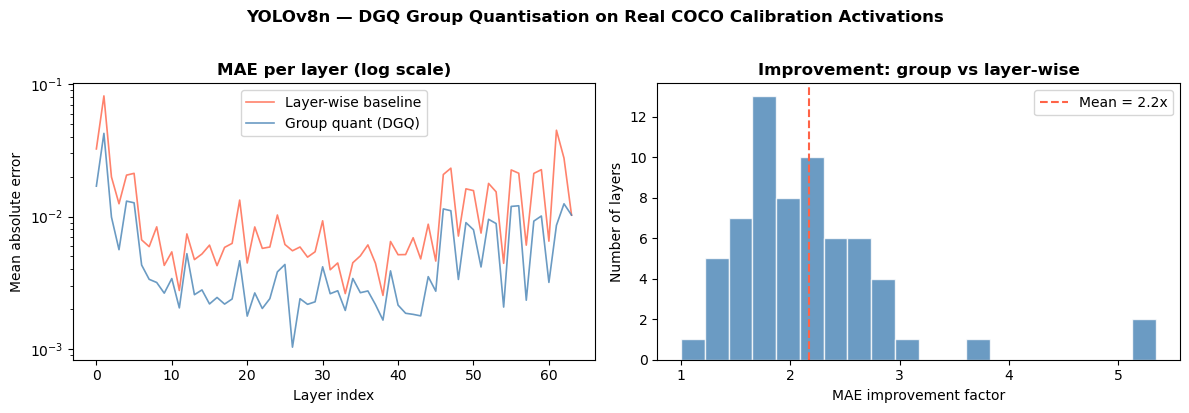

Figure saved to yolo_results.png


In [53]:
# Results summary
improvements = [r['improvement'] for r in results.values() if r['improvement'] != float('inf')]
mae_groups   = [r['mae_group']   for r in results.values()]
mae_lws      = [r['mae_lw']      for r in results.values()]
dims         = [r['dim']         for r in results.values()]

print('=' * 55)
print('YOLOv8n DGQ Results (8-bit, K=8, 64 COCO images)')
print('=' * 55)
print(f'Layers quantised:       {len(results)}')
print(f'Mean MAE (group DGQ):   {np.mean(mae_groups):.6f}')
print(f'Mean MAE (layer-wise):  {np.mean(mae_lws):.6f}')
print(f'Mean improvement:       {np.mean(improvements):.1f}x')
print(f'Dimension selected:')
print(f'  pixel:   {dims.count("pixel")} layers')
print(f'  channel: {dims.count("channel")} layers')

# Results figure
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
ax.plot(mae_lws,    color='tomato',    alpha=0.8, linewidth=1.2, label='Layer-wise baseline')
ax.plot(mae_groups, color='steelblue', alpha=0.8, linewidth=1.2, label='Group quant (DGQ)')
ax.set_yscale('log')
ax.set_title('MAE per layer (log scale)', fontweight='bold')
ax.set_xlabel('Layer index')
ax.set_ylabel('Mean absolute error')
ax.legend()

ax = axes[1]
ax.hist(improvements, bins=20, color='steelblue', alpha=0.8, edgecolor='white')
ax.axvline(np.mean(improvements), color='tomato', linestyle='--',
           linewidth=1.5, label=f'Mean = {np.mean(improvements):.1f}x')
ax.set_title('Improvement: group vs layer-wise', fontweight='bold')
ax.set_xlabel('MAE improvement factor')
ax.set_ylabel('Number of layers')
ax.legend()

plt.suptitle(
    'YOLOv8n — DGQ Group Quantisation on Real COCO Calibration Activations',
    fontweight='bold', y=1.02
)
plt.tight_layout()
plt.savefig('yolo_results.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved to yolo_results.png')